# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 1. 

In [59]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Task 1 - PubMedQA

Steps:
* Import the dataset
* Medical QA pipeline: baseline system
* Evaluation -- some simple metrics as an example; a naive baseline as input to the example

In [60]:
# Load PubMedQA (the main labeled split is "pqa_labeled"). 
# The other splits are "pqa_unlabeled", which has no yes/no/maybe labels, 
# and "pqa_artificial", which consists of automatically generated 
# questions and answers. 
dataset = load_dataset("pubmed_qa", "pqa_labeled")

# Inspect the dataset
print(dataset)

# Look at the first example
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
{'pubid': 21645374, 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole wi

To access the important fields:

In [61]:
example = dataset["train"][0]

question = example["question"]
context_paragraphs = example["context"]["contexts"]
label = example["final_decision"]

print("Question:", question)
print("Label:", label)
print("What is inside the context? These are the keys to the context dictionary:", list(example["context"].keys()))
print("The 'context' is an abstract that has been split into paragraphs. \n First context paragraph:", context_paragraphs[0])

Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Label: yes
What is inside the context? These are the keys to the context dictionary: ['contexts', 'labels', 'meshes', 'reasoning_required_pred', 'reasoning_free_pred']
The 'context' is an abstract that has been split into paragraphs. 
 First context paragraph: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.


Combine context paragraphs (common preprocessing step)

In [62]:
def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

print(dataset["train"][0]["combined_context"][:500])

Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has b


The short answers are stored in the field "final_decision" and can take the following values: 

In [63]:
np.unique(dataset["train"]["final_decision"])

array(['maybe', 'no', 'yes'], dtype='<U5')

The long answers look like this and your system could either extract the answer sentences from the context or generate them. Producing long answers is optional.

In [64]:
dataset["train"][0]["long_answer"]

'Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar strands to form a ring structure surrounding the nucleus during developmental PCD. Also, for the first time, we have shown the feasibility for the use of CsA in a whole plant system. Overall, our findings implicate the mitochondria as playing a critical and early role in developmentally regulated PCD in the lace plant.'

## Baseline: Word2Vec + Decision Tree / Random Forest

In [65]:
import re
import random
import matplotlib.pyplot as plt

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [66]:
label2id = {"yes": 0, "no": 1, "maybe": 2}
id2label = {v: k for k, v in label2id.items()}

def simple_tokenize(text):
    text = text.lower()
    return re.findall(r"[a-z]+(?:[-'][a-z]+)*|\d+(?:\.\d+)?", text)

def add_features(example):
    question = example["question"]
    context = example["combined_context"]
    text = question + " " + context
    
    example["text"] = text
    example["tokens"] = simple_tokenize(text)
    example["label_id"] = label2id[example["final_decision"]]
    return example

dataset = dataset.map(add_features)

print(dataset["train"][0]["question"])
print(dataset["train"][0]["final_decision"])
print(dataset["train"][0]["tokens"][:30])

Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
yes
['do', 'mitochondria', 'play', 'a', 'role', 'in', 'remodelling', 'lace', 'plant', 'leaves', 'during', 'programmed', 'cell', 'death', 'programmed', 'cell', 'death', 'pcd', 'is', 'the', 'regulated', 'death', 'of', 'cells', 'within', 'an', 'organism', 'the', 'lace', 'plant']


In [67]:
df = dataset["train"].to_pandas()

print("Total size:", len(df))
print(df["final_decision"].value_counts())
print(df["final_decision"].value_counts(normalize=True))

train_df, val_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Total size: 1000
final_decision
yes      552
no       338
maybe    110
Name: count, dtype: int64
final_decision
yes      0.552
no       0.338
maybe    0.110
Name: proportion, dtype: float64
Train: 700
Validation: 300


In [68]:
def ensure_token_list(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    elif isinstance(x, list):
        return x
    else:
        return list(x)

train_df["tokens"] = train_df["tokens"].apply(ensure_token_list)
val_df["tokens"] = val_df["tokens"].apply(ensure_token_list)

In [69]:
train_sentences = train_df["tokens"].tolist()

train_sentences = [
    [str(token) for token in sent]
    for sent in train_sentences
]

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=1,
    sg=1,          # skip-gram
    epochs=15,
    seed=SEED
)

print("Vocabulary size:", len(w2v_model.wv))
print("Vector size:", w2v_model.vector_size)

Vocabulary size: 13678
Vector size: 100


In [70]:
def average_word_vectors(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train = np.vstack(
    train_df["tokens"].apply(lambda x: average_word_vectors(x, w2v_model)).values
)
X_val = np.vstack(
    val_df["tokens"].apply(lambda x: average_word_vectors(x, w2v_model)).values
)

y_train = train_df["label_id"].values
y_val = val_df["label_id"].values

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (700, 100)
X_val shape: (300, 100)
y_train shape: (700,)
y_val shape: (300,)


In [71]:
dt_param_grid = {
    "max_depth": [10, 20, 40, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        class_weight="balanced",
        random_state=SEED
    ),
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
val_pred_dt = best_dt.predict(X_val)

dt_acc = accuracy_score(y_val, val_pred_dt)
dt_f1 = f1_score(y_val, val_pred_dt, average="macro")

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Decision Tree CV Macro-F1:", dt_grid.best_score_)
print("Decision Tree validation accuracy:", dt_acc)
print("Decision Tree validation macro-F1:", dt_f1)
print(classification_report(
    y_val,
    val_pred_dt,
    target_names=["yes", "no", "maybe"],
    zero_division=0
))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5}
Best Decision Tree CV Macro-F1: 0.35502222013859935
Decision Tree validation accuracy: 0.39
Decision Tree validation macro-F1: 0.3349272124565879
              precision    recall  f1-score   support

         yes       0.54      0.45      0.49       166
          no       0.33      0.35      0.34       101
       maybe       0.14      0.24      0.18        33

    accuracy                           0.39       300
   macro avg       0.34      0.34      0.33       300
weighted avg       0.42      0.39      0.40       300



In [72]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 40, None],
    "min_samples_leaf": [1, 2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
val_pred_rf = best_rf.predict(X_val)

rf_acc = accuracy_score(y_val, val_pred_rf)
rf_f1 = f1_score(y_val, val_pred_rf, average="macro")

print("Best Random Forest Params:", rf_grid.best_params_)
print("Best Random Forest CV Macro-F1:", rf_grid.best_score_)
print("Random Forest validation accuracy:", rf_acc)
print("Random Forest validation macro-F1:", rf_f1)
print(classification_report(
    y_val,
    val_pred_rf,
    target_names=["yes", "no", "maybe"],
    zero_division=0
))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest Params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best Random Forest CV Macro-F1: 0.3496187763375814
Random Forest validation accuracy: 0.5533333333333333
Random Forest validation macro-F1: 0.34826887934014916
              precision    recall  f1-score   support

         yes       0.58      0.81      0.68       166
          no       0.45      0.31      0.36       101
       maybe       0.00      0.00      0.00        33

    accuracy                           0.55       300
   macro avg       0.34      0.37      0.35       300
weighted avg       0.47      0.55      0.50       300



In [73]:
results_df = pd.DataFrame([
    {
        "model": "Word2Vec + Decision Tree",
        "cv_macro_f1": dt_grid.best_score_,
        "val_accuracy": dt_acc,
        "val_macro_f1": dt_f1,
        "best_params": str(dt_grid.best_params_)
    },
    {
        "model": "Word2Vec + Random Forest",
        "cv_macro_f1": rf_grid.best_score_,
        "val_accuracy": rf_acc,
        "val_macro_f1": rf_f1,
        "best_params": str(rf_grid.best_params_)
    }
])

results_df = results_df.sort_values(by="val_macro_f1", ascending=False).reset_index(drop=True)
results_df

,model,cv_macro_f1,val_accuracy,val_macro_f1,best_params
0,Word2Vec + Random Forest,0.349619,0.553333,0.348269,"{'max_depth': 10, 'min_samples_leaf': 5, 'n_es..."
1,Word2Vec + Decision Tree,0.355022,0.390000,0.334927,"{'criterion': 'entropy', 'max_depth': 20, 'min..."


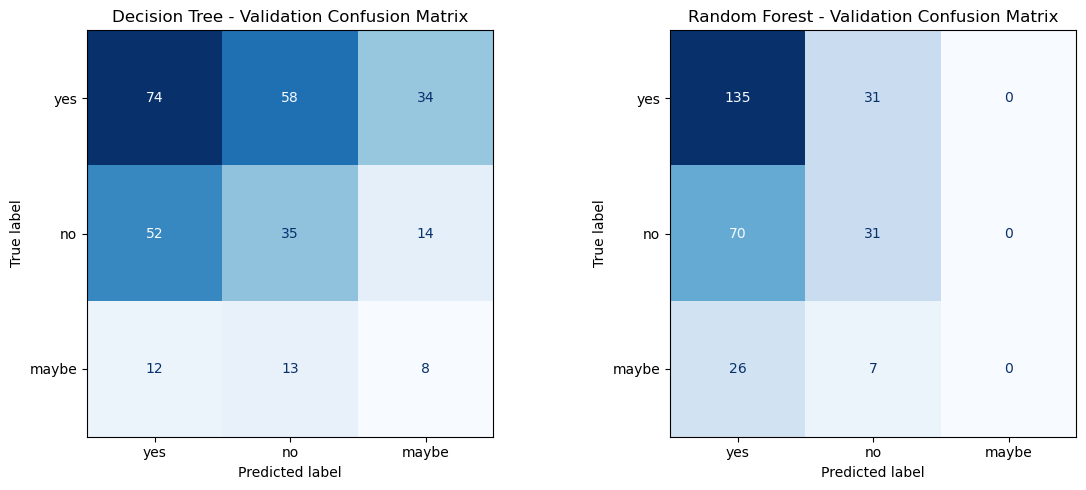

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_order = [0, 1, 2]
label_names = ["yes", "no", "maybe"]

cm_dt = confusion_matrix(y_val, val_pred_dt, labels=label_order)
cm_rf = confusion_matrix(y_val, val_pred_rf, labels=label_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_names)
disp_dt.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Decision Tree - Validation Confusion Matrix")

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_names)
disp_rf.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Random Forest - Validation Confusion Matrix")

plt.tight_layout()
plt.show()